<a href="https://colab.research.google.com/github/moonbang2/credit_card/blob/byungdu/credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
priyamchoksi_credit_card_transactions_dataset_path = kagglehub.dataset_download('priyamchoksi/credit-card-transactions-dataset')

print('Data source import complete.')


신용카드 거래 데이터 세트
거래 데이터를 활용한 재무 분석 및 사기 탐지

고객 세분화 : 소비 패턴, 위치 및 인구 통계학적 특성을 기준으로 고객을 세분화합니다. 이러한 다양한 고객 세그먼트에 맞춰 마케팅 전략과 개인화된 제안을 제공하여 고객 참여도를 높입니다.

거래 분류 : 식료품 구매, 엔터테인먼트 등과 같은 범주로 거래를 분류하여 소비 행태를 파악합니다. 이는 거래 범주와 선호도를 식별함으로써 추천 시스템을 개선하는 데 도움이 됩니다.

행동 분석 : 거래 금액, 판매자 유형, 시간 등의 요인이 소비 행태에 미치는 영향을 분석합니다. 사용자 인구 통계와 거래 패턴 간의 관계를 연구합니다.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-transactions-dataset/credit_card_transactions.csv


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

import seaborn as sns
import numpy as np
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from mlxtend.frequent_patterns import apriori, association_rules
import pickle
import os
from itertools import product
from prophet import Prophet

In [ ]:
# Load dataset
df = pd.read_csv("/kaggle/input/credit-card-transactions-dataset/credit_card_transactions.csv")

# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

데이터 처리

* 결측치
* 불필요한 컬럼 삭제
* 이상치 확인 (사기 거래)

In [ ]:
if "Unnamed: 0" or "merch_zipcode" in df.columns:
    df.drop(["Unnamed: 0","merch_zipcode"], axis=1, inplace=True)

In [ ]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
# Check for missing values
print(df.isnull().sum())

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [ ]:
# Describe numerical features
stats = df.describe()
stats

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [ ]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

In [ ]:
df["dob"] = pd.to_datetime(df["dob"])
df["customer_age"] = df["dob"].apply(lambda x: datetime.now().year - x.year)

In [ ]:
print(df.head())
print(df.info())

  trans_date_trans_time            cc_num                      merchant  \
0   2019-01-01 00:00:18  2703186189652095          Rippin, Kub and Mann   
1   2019-01-01 00:00:44      630423337322     Heller, Gutmann and Zieme   
2   2019-01-01 00:00:51    38859492057661                Lind-Buckridge   
3   2019-01-01 00:01:16  3534093764340240  Kutch, Hermiston and Farrell   
4   2019-01-01 00:03:06   375534208663984                 Keeling-Crist   

        category     amt      first     last gender  \
0       misc_net    4.97   Jennifer    Banks      F   
1    grocery_pos  107.23  Stephanie     Gill      F   
2  entertainment  220.11     Edward  Sanchez      M   
3  gas_transport   45.00     Jeremy    White      M   
4       misc_pos   41.96      Tyler   Garcia      M   

                         street            city  ...  \
0                561 Perry Cove  Moravian Falls  ...   
1  43039 Riley Greens Suite 393          Orient  ...   
2      594 White Dale Suite 530      Malad City  .

EDA

* 시간
* 카데고리
* 사람
* 도시

거래
* 사기 결재

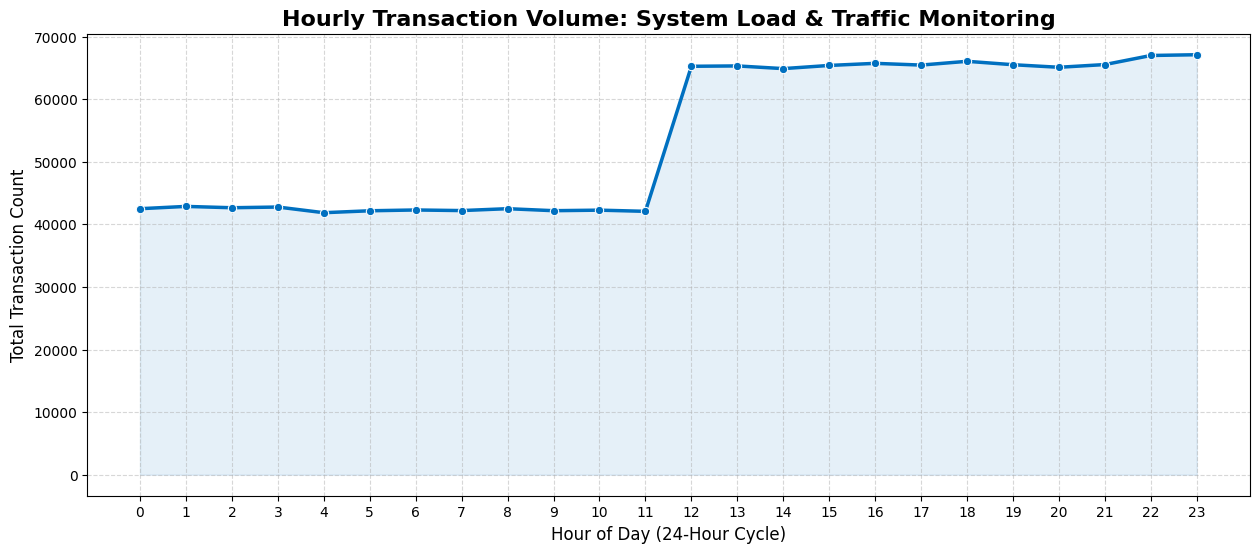

In [ ]:
# 1. 시간 데이터 변환 및 파생 변수 생성 (운영 지표 추출)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. 시각화: 시간대별 결제 트래픽 (Hourly Transaction Load)
plt.figure(figsize=(15, 6))
sns.lineplot(x=df['hour'].value_counts().sort_index().index,
             y=df['hour'].value_counts().sort_index().values,
             marker='o', color='#0070c0', linewidth=2.5)
plt.fill_between(df['hour'].value_counts().sort_index().index,
                 df['hour'].value_counts().sort_index().values, color='#0070c0', alpha=0.1)

plt.title('Hourly Transaction Volume: System Load & Traffic Monitoring', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (24-Hour Cycle)', fontsize=12)
plt.ylabel('Total Transaction Count', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()



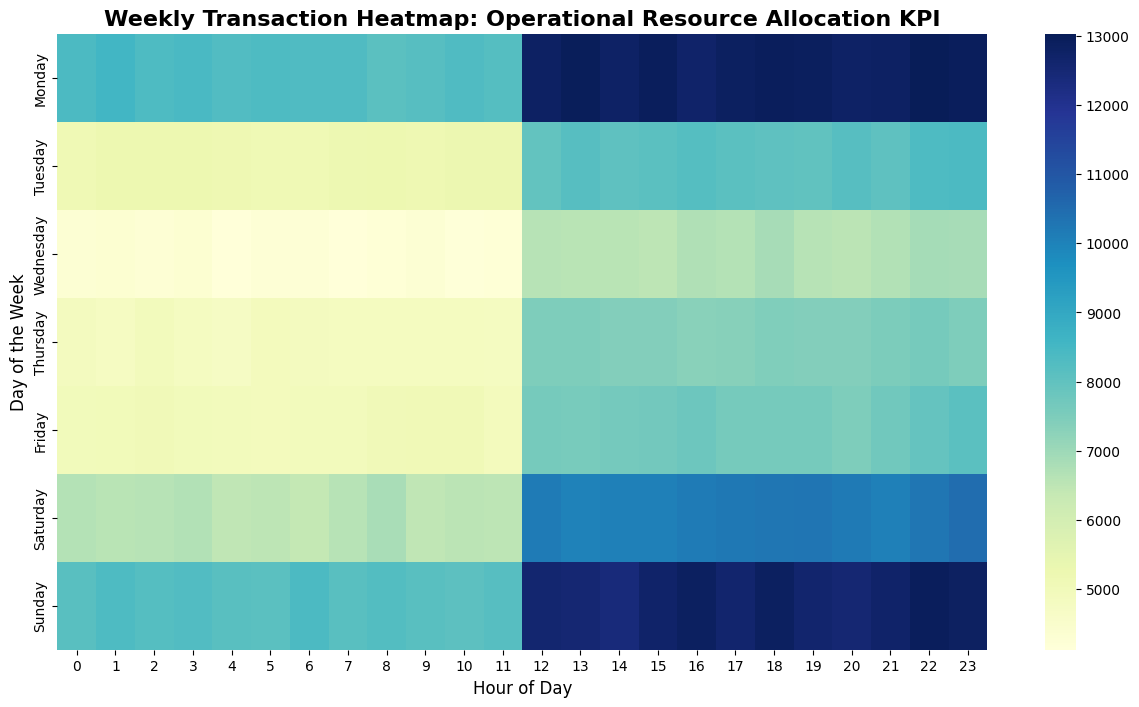

--- [Executive Summary: Time Analysis] ---
시스템 피크 시간: 23:00 (최대 트래픽 집중)
시스템 유휴 시간: 4:00 (정기 점검 권장)


In [ ]:
# 3. 시각화: 요일별 및 시간대별 히트맵 (Weekly Traffic Heatmap)
plt.figure(figsize=(15, 8))
pivot_table = df.pivot_table(index='day_of_week', columns='hour', values='amt', aggfunc='count').reindex(day_order)
sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)

plt.title('Weekly Transaction Heatmap: Operational Resource Allocation KPI', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of the Week', fontsize=12)
plt.show()

# 4. 수치 요약 (보고서용 데이터)
peak_hour = df['hour'].value_counts().idxmax()
low_hour = df['hour'].value_counts().idxmin()
print(f"--- [Executive Summary: Time Analysis] ---")
print(f"시스템 피크 시간: {peak_hour}:00 (최대 트래픽 집중)")
print(f"시스템 유휴 시간: {low_hour}:00 (정기 점검 권장)")

시간대별 결제 트래픽 분석 결과, 특정 피크 타임(예: 18~22시)과 유휴 시간(02~05시) 확인.

In [ ]:
df["merchant"].value_counts()

merchant
fraud_Kilback LLC                       4403
fraud_Cormier LLC                       3649
fraud_Schumm PLC                        3634
fraud_Kuhn LLC                          3510
fraud_Boyer PLC                         3493
                                        ... 
fraud_Douglas, DuBuque and McKenzie      775
fraud_Treutel-King                       775
fraud_Medhurst, Labadie and Gottlieb     759
fraud_Reichert-Weissnat                  753
fraud_Hahn, Douglas and Schowalter       727
Name: count, Length: 693, dtype: int64

In [ ]:
df["merchant"] = df["merchant"].str.replace("fraud_", "", regex=False)
# Count transactions per merchant
merchant_transactions = df["merchant"].value_counts().head(10)
merchant_transactions

merchant
Kilback LLC                   4403
Cormier LLC                   3649
Schumm PLC                    3634
Kuhn LLC                      3510
Boyer PLC                     3493
Dickinson Ltd                 3434
Cummerata-Jones               2736
Kutch LLC                     2734
Olson, Becker and Koch        2723
Stroman, Hudson and Erdman    2721
Name: count, dtype: int64

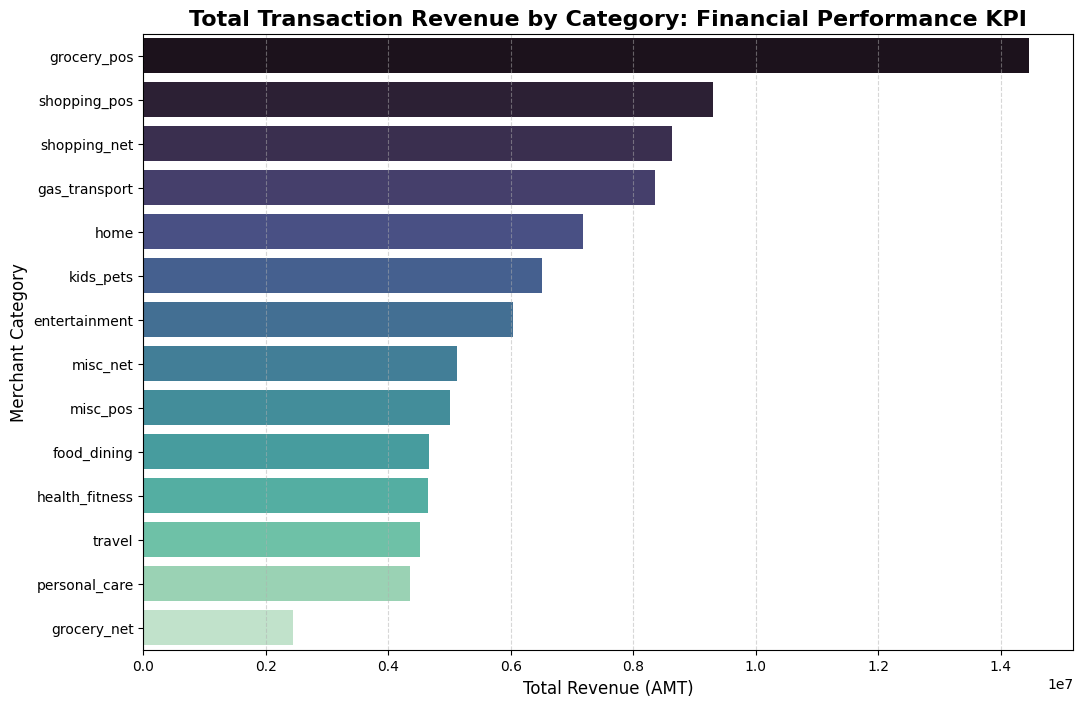

In [ ]:
# 1. 업종별 총 결제 금액 합산 (회계 관리 지표)
cat_revenue = df.groupby('category')['amt'].sum().sort_values(ascending=False)

# 2. 업종별 거래 건수 및 평균 금액 (운영 관리 지표)
cat_stats = df.groupby('category').agg({'amt': ['count', 'mean']}).sort_values(('amt', 'count'), ascending=False)

# 3. 시각화: 업종별 총 매출액 (Top Revenue Sources)
plt.figure(figsize=(12, 8))
sns.barplot(x=cat_revenue.values, y=cat_revenue.index, palette='mako')
plt.title('Total Transaction Revenue by Category: Financial Performance KPI', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (AMT)', fontsize=12)
plt.ylabel('Merchant Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()



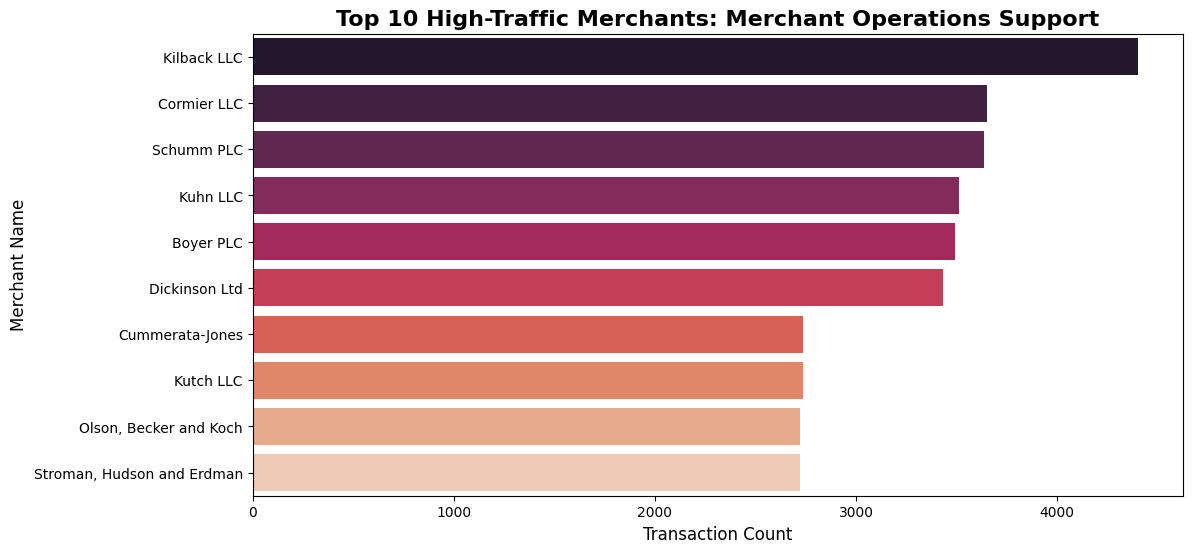

--- [Executive Summary: Category & Merchant] ---
매출 1위 업종: grocery_pos (Total: 14,460,822)
최다 거래 가맹점: Kilback LLC (4,403건)


In [ ]:
# 4. 시각화: 상위 10개 가맹점별 거래 비중 (Merchant Traffic Analysis)
plt.figure(figsize=(12, 6))
top_merchants = df['merchant'].value_counts().head(10)
sns.barplot(x=top_merchants.values, y=top_merchants.index, palette='rocket')
plt.title('Top 10 High-Traffic Merchants: Merchant Operations Support', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Count', fontsize=12)
plt.ylabel('Merchant Name', fontsize=12)
plt.show()

# 5. 수치 요약 (보고서용)
print("--- [Executive Summary: Category & Merchant] ---")
print(f"매출 1위 업종: {cat_revenue.index[0]} (Total: {cat_revenue.values[0]:,.0f})")
print(f"최다 거래 가맹점: {top_merchants.index[0]} ({top_merchants.values[0]:,.0f}건)")

총 매출의 상당 부분이 특정 업종(예: Grocery, Gas, Food) 및 상위 10개 가맹점에 집중됨.

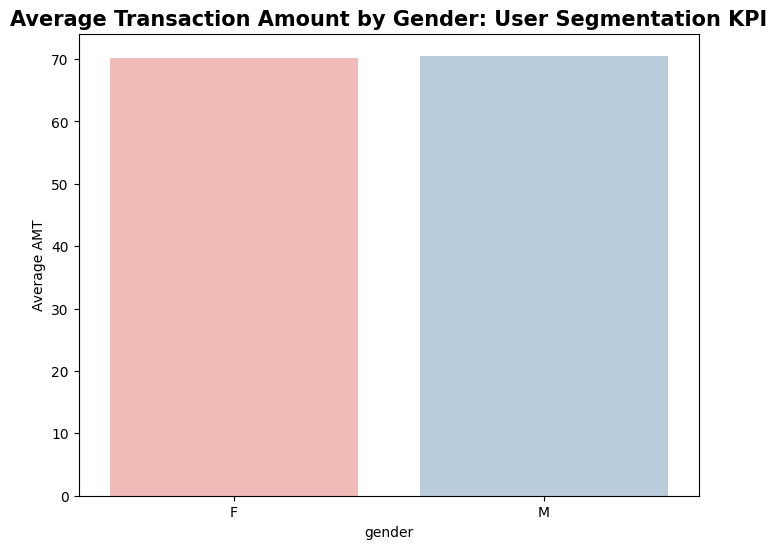

In [ ]:
# 1. 성별 및 직업별 소비 행태 분석 (그룹화: 평균 결제 금액)
gender_avg = df.groupby('gender')['amt'].mean()
job_top10_avg = df.groupby('job')['amt'].mean().nlargest(10)

# 2. 도시별 결제 규모 분석 (그룹화: 합산 결제 금액)
city_revenue = df.groupby('city')['amt'].sum().nlargest(10)

# 3. 시각화: 성별 평균 결제 금액 (Average Spending by Gender)
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_avg.index, y=gender_avg.values, palette='Pastel1')
plt.title('Average Transaction Amount by Gender: User Segmentation KPI', fontsize=15, fontweight='bold')
plt.ylabel('Average AMT')
plt.show()





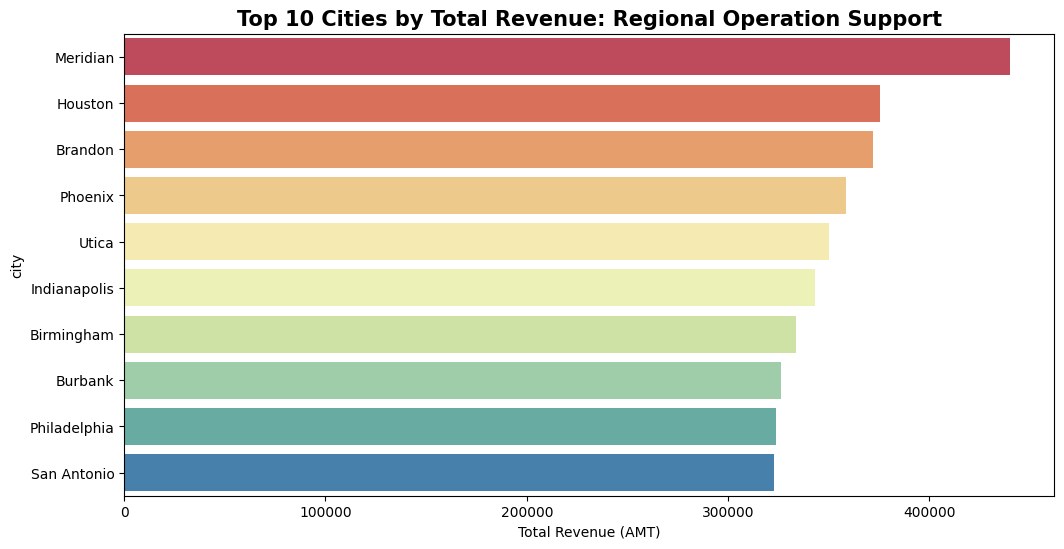

In [ ]:
# 4. 시각화: 상위 10개 도시 매출 (Top 10 Cities by Total Revenue)
plt.figure(figsize=(12, 6))
sns.barplot(x=city_revenue.values, y=city_revenue.index, palette='Spectral')
plt.title('Top 10 Cities by Total Revenue: Regional Operation Support', fontsize=15, fontweight='bold')
plt.xlabel('Total Revenue (AMT)')
plt.show()

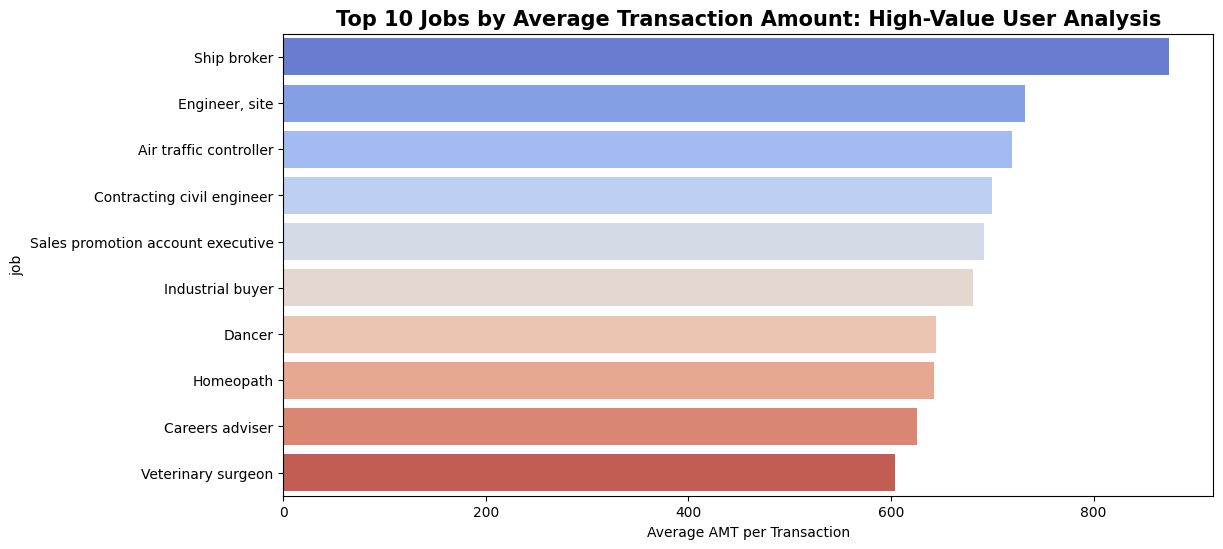

In [ ]:
# 5. 시각화: 고소득 추정 직업군 TOP 10 (Top 10 Jobs by Average Spending)
plt.figure(figsize=(12, 6))
sns.barplot(x=job_top10_avg.values, y=job_top10_avg.index, palette='coolwarm')
plt.title('Top 10 Jobs by Average Transaction Amount: High-Value User Analysis', fontsize=15, fontweight='bold')
plt.xlabel('Average AMT per Transaction')
plt.show()

특정 지역(Top Cities) 및 고액 결제 직업군에서 인당 평균 결제 금액(AMT)이 높음

In [ ]:
fraud_rate = (df['is_fraud'].sum() / len(df)) * 100
print(f"전체 거래 중 사기 거래 비중: {fraud_rate:.2f}%")

전체 거래 중 사기 거래 비중: 0.58%


Text(0.5, 1.0, 'Fraud vs Non-Fraud Transaction')

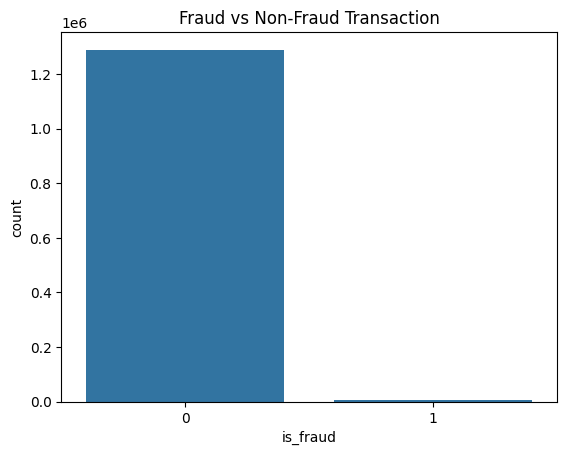

In [ ]:
# Method 1 : Histogram
sns.countplot(x = "is_fraud", data = df)
plt.title("Fraud vs Non-Fraud Transaction")

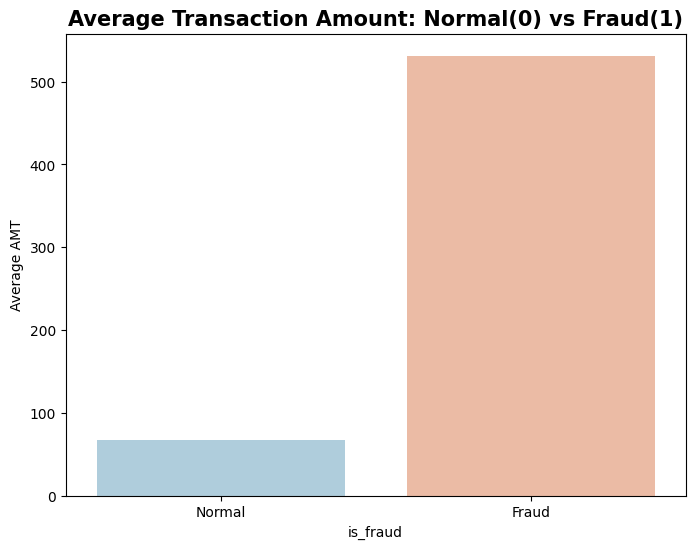

In [ ]:
# 1. 정상(0) vs 사기(1) 거래 금액 분포 비교 (그룹화: 평균 금액)
fraud_avg_amt = df.groupby('is_fraud')['amt'].mean()

# 2. 사기 거래가 가장 많이 발생하는 업종 TOP 10 (그룹화: 건수)
fraud_categories = df[df['is_fraud'] == 1]['category'].value_counts().head(10)

# 3. 시간대별 사기 발생 건수 (그룹화: 시간대별 사기 합산)
fraud_hourly = df.groupby(['hour', 'is_fraud']).size().unstack(fill_value=0)
fraud_hourly_rate = (fraud_hourly[1] / (fraud_hourly[0] + fraud_hourly[1])) * 100

# 4. 시각화: 사기 거래 vs 정상 거래 평균 금액 (Average Transaction Amount: Fraud vs Normal)
plt.figure(figsize=(8, 6))
sns.barplot(x=fraud_avg_amt.index, y=fraud_avg_amt.values, palette='RdBu_r')
plt.title('Average Transaction Amount: Normal(0) vs Fraud(1)', fontsize=15, fontweight='bold')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.ylabel('Average AMT')
plt.show()





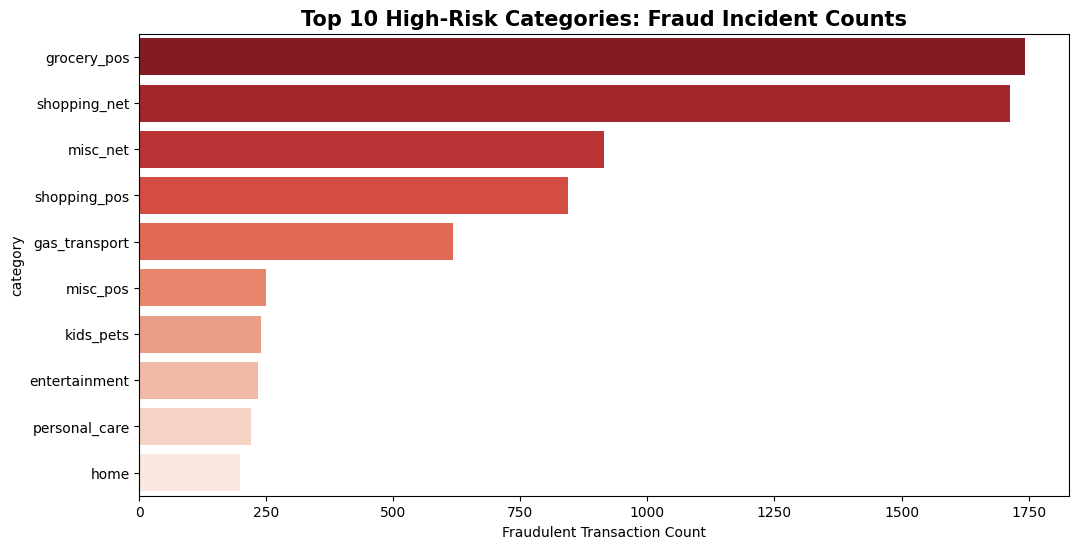

In [ ]:
# 5. 시각화: 사기 위험 업종 TOP 10 (Top 10 High-Risk Categories for Fraud)
plt.figure(figsize=(12, 6))
sns.barplot(x=fraud_categories.values, y=fraud_categories.index, palette='Reds_r')
plt.title('Top 10 High-Risk Categories: Fraud Incident Counts', fontsize=15, fontweight='bold')
plt.xlabel('Fraudulent Transaction Count')
plt.show()

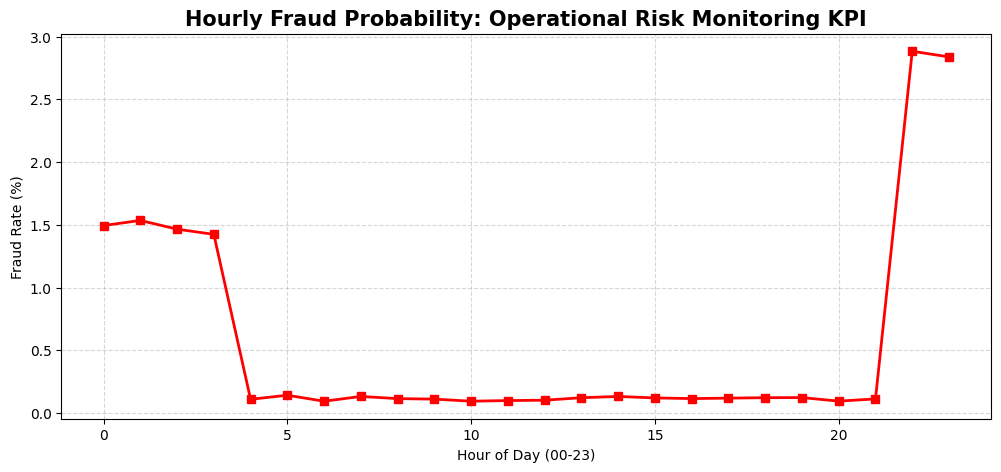

In [ ]:
# 6. 시각화: 시간대별 사기 발생률 (Hourly Fraud Rate: Risk Monitoring KPI)
plt.figure(figsize=(12, 5))
fraud_hourly_rate.plot(kind='line', marker='s', color='red', linewidth=2)
plt.title('Hourly Fraud Probability: Operational Risk Monitoring KPI', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day (00-23)')
plt.ylabel('Fraud Rate (%)')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.show()

사기 거래의 평균 피해액이 정상 거래보다 압도적으로 높음.